In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
!pip install torch torchvision matplotlib numpy opencv-python
!pip install tqdm

In [5]:
# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# Torchvision
from torchvision import datasets, transforms, models

# OpenCV
import cv2

# Matplotlib & Numpy
import matplotlib.pyplot as plt
import numpy as np

# Device configuration: CPU or GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [6]:
data_dir = "/content/drive/MyDrive/fer2013"


In [7]:
import os
print(os.listdir(data_dir))


['test', 'train']


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

train_dataset = datasets.ImageFolder(root=data_dir + "/train", transform=transform)
test_dataset  = datasets.ImageFolder(root=data_dir + "/test", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
print(train_dataset.classes)


In [9]:
from torchvision import models
import torch.nn as nn

model = models.mobilenet_v2(pretrained=True)
model.classifier[1] = nn.Linear(model.last_channel, 7)
model = model.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 212MB/s]


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

print("Loss and Optimizer ready!")


Loss and Optimizer ready!


In [ ]:
num_epochs = 1

for epoch in range(num_epochs):
    model.train()
    correct = 0
    total = 0

    for i, (images, labels) in enumerate(train_loader):
        if i >= 50:
            break

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        del images, labels, outputs, loss
        torch.cuda.empty_cache()

        print(f"Batch {i} done")

    print(f"Epoch Accuracy: {100 * correct / total:.2f}%")


Batch 0 done
Batch 1 done
Batch 2 done
Batch 3 done
Batch 4 done
Batch 5 done
Batch 6 done
Batch 7 done
Batch 8 done
Batch 9 done
Batch 10 done
Batch 11 done
Batch 12 done
Batch 13 done
Batch 14 done
Batch 15 done
Batch 16 done
Batch 17 done
Batch 18 done
Batch 19 done
Batch 20 done
Batch 21 done
Batch 22 done
Batch 23 done
Batch 24 done
Batch 25 done
Batch 26 done
Batch 27 done
Batch 28 done
Batch 29 done
Batch 30 done
Batch 31 done
Batch 32 done
Batch 33 done
Batch 34 done
Batch 35 done
Batch 36 done
Batch 37 done
Batch 38 done
Batch 39 done
Batch 40 done
Batch 41 done
Batch 42 done
Batch 43 done
Batch 44 done
Batch 45 done
Batch 46 done
Batch 47 done
Batch 48 done
Batch 49 done
Epoch Accuracy: 22.50%


In [ ]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    correct = 0
    total = 0

    for i, (images, labels) in enumerate(train_loader):
        if i >= 300:
            break

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        del images, labels, outputs, loss
        torch.cuda.empty_cache()


    print(f"Epoch Accuracy: {100 * correct / total:.2f}%")


Epoch Accuracy: 38.17%
Epoch Accuracy: 39.33%
Epoch Accuracy: 40.92%
Epoch Accuracy: 40.75%
Epoch Accuracy: 40.58%


In [ ]:
#Data + Augmentation
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((96,96)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(0, translate=(0.1,0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((96,96)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

train_dataset = datasets.ImageFolder(data_dir+"/train", transform=train_transform)
test_dataset  = datasets.ImageFolder(data_dir+"/test", transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16)


In [ ]:
#model
import torch
import torch.nn as nn
from torchvision import models

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 206MB/s]


In [ ]:
#loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)


In [ ]:
from tqdm import tqdm

num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        acc = 100 * correct / total
        loop.set_postfix(loss=loss.item(), acc=f"{acc:.2f}%")

    print(f"✅ Epoch {epoch+1} Accuracy: {100 * correct / total:.2f}%\n")


Epoch 1/20: 100%|██████████| 1798/1798 [1:27:08<00:00,  2.91s/it, acc=53.16%, loss=1.02]


✅ Epoch 1 Accuracy: 53.16%



Epoch 2/20: 100%|██████████| 1798/1798 [02:34<00:00, 11.63it/s, acc=56.97%, loss=1.26]


✅ Epoch 2 Accuracy: 56.97%



Epoch 3/20: 100%|██████████| 1798/1798 [02:37<00:00, 11.44it/s, acc=59.53%, loss=2.84]


...

✅ Epoch 18 Accuracy: 73.50%



Epoch 19/20: 100%|██████████| 1798/1798 [02:35<00:00, 11.56it/s, acc=74.19%, loss=2.67]


✅ Epoch 19 Accuracy: 74.19%



Epoch 20/20: 100%|██████████| 1798/1798 [02:35<00:00, 11.56it/s, acc=74.66%, loss=1.45]

✅ Epoch 20 Accuracy: 74.66%



In [ ]:
torch.save(model.state_dict(), "deepface_strong_model.pth")
print("💾 Model Saved Successfully!")


💾 Model Saved Successfully!


In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/deepface_strong_model.pth")

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# build model structure again
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("✅ Model structure loaded")


✅ Model structure loaded


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
#load model we trained later
model.load_state_dict(torch.load("/content/drive/MyDrive/deepface_strong_model.pth"))
print("🔥 Your trained model is loaded!")


🔥 Your trained model is loaded!


In [ ]:
# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last block
for param in model.layer4.parameters():
    param.requires_grad = True

# Unfreeze classifier
for param in model.fc.parameters():
    param.requires_grad = True

print("✅ Fine-tuning layers are ready")


✅ Fine-tuning layers are ready


In [ ]:
optimizer = torch.optim.Adam([
    {'params': model.layer4.parameters(), 'lr': 1e-5},
    {'params': model.fc.parameters(), 'lr': 1e-4}
])

criterion = nn.CrossEntropyLoss()
print("✅ Fine-tuning optimizer ready")


✅ Fine-tuning optimizer ready


In [ ]:
from tqdm import tqdm

num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    correct = 0
    total = 0
    running_loss = 0

    for i, (images, labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")):

        if i >= 300:  #batches
            break

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        del images, labels, outputs, loss
        torch.cuda.empty_cache()

    acc = 100 * correct / total
    print(f"✅ Epoch {epoch+1} | Loss: {running_loss/(i+1):.4f} | Accuracy: {acc:.2f}%")


Epoch 1/5:  17%|█▋        | 300/1798 [37:51<3:09:02,  7.57s/it]


✅ Epoch 1 | Loss: 1.8258 | Accuracy: 23.23%


Epoch 2/5:  17%|█▋        | 300/1798 [29:23<2:26:45,  5.88s/it]


✅ Epoch 2 | Loss: 1.7839 | Accuracy: 25.35%


Epoch 3/5:  17%|█▋        | 300/1798 [23:30<1:57:25,  4.70s/it]


✅ Epoch 3 | Loss: 1.7946 | Accuracy: 24.69%


Epoch 4/5:  17%|█▋        | 300/1798 [20:03<1:40:10,  4.01s/it]


✅ Epoch 4 | Loss: 1.7712 | Accuracy: 26.17%


Epoch 5/5:  17%|█▋        | 300/1798 [17:50<1:29:05,  3.57s/it]

✅ Epoch 5 | Loss: 1.7677 | Accuracy: 26.27%


In [ ]:
# load ResNet18

In [10]:
import torch
import torch.nn as nn
from torchvision import models

num_classes = 7

model = models.resnet18(pretrained=True)

# change the last layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

model


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 200MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Ready to train!")


Ready to train!


In [12]:

import torch
from tqdm import tqdm
import os

save_path = "/content/drive/MyDrive/emotion_checkpoint.pth"
num_epochs = 15
start_epoch = 0
best_acc = 0

# work from last model
if os.path.exists(save_path):
    print("🔁 Loading previous checkpoint...")
    checkpoint = torch.load(save_path, map_location=device)
    model.load_state_dict(checkpoint['model'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    start_epoch = checkpoint['epoch'] + 1
    best_acc = checkpoint['best_acc']
    print(f"✅ Resuming from Epoch {start_epoch}")


for epoch in range(start_epoch, num_epochs):
    model.train()
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        loop.set_postfix(acc=100*correct/total)

    accuracy = 100 * correct / total
    print(f"✅ Epoch {epoch+1} Accuracy: {accuracy:.2f}%")

 # saving
    torch.save({
        'epoch': epoch,
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'best_acc': best_acc
    }, save_path)

    print("💾 Checkpoint Saved!")


🔁 Loading previous checkpoint...
✅ Resuming from Epoch 15


In [12]:
torch.save(model.state_dict(), "emotion_resnet18.pth")
print("Model Saved!")


Model Saved!


In [13]:
for param in model.parameters():
    param.requires_grad = False


In [14]:
for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True


In [15]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.00001
)


In [ ]:
from tqdm import tqdm
import torch

num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    correct = 0
    total = 0

    loop = tqdm(enumerate(train_loader),
                total=len(train_loader),
                desc=f"FineTune Epoch {epoch+1}/{num_epochs}")

    for i, (images, labels) in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        #  20 batch
        if i % 20 == 0:
            loop.set_postfix(acc=f"{100*correct/total:.2f}%")

        # clean memory
        del images, labels, outputs, loss
        torch.cuda.empty_cache()

    print(f"✅ FineTune Epoch {epoch+1} Accuracy: {100*correct/total:.2f}%")

In [ ]:
torch.save(model.state_dict(),
           "/content/drive/MyDrive/emotion_resnet18_final.pth")

print("Final Model Saved in Drive!")

Final Model Saved in Drive!


In [16]:
model.load_state_dict(
    torch.load("/content/drive/MyDrive/emotion_resnet18_final.pth",
               map_location=device)
)
model.eval()

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [ ]:
from tqdm import tqdm
import time

model.eval()

correct = 0
total = 0

start_time = time.time()

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

end_time = time.time()

print(f"\n Test Accuracy: {100*correct/total:.2f}%")
print(f"Evaluation Time: {end_time - start_time:.2f} seconds")

Evaluating: 100%|██████████| 114/114 [1:00:46<00:00, 31.99s/it]


 Test Accuracy: 58.31%
Evaluation Time: 3646.67 seconds


In [17]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Data Augmentation
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # color adjustment
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

# Load datasets
train_dataset = datasets.ImageFolder(root=data_dir + "/train", transform=train_transform)
test_dataset  = datasets.ImageFolder(root=data_dir + "/test", transform=test_transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(" DataLoaders Ready with Augmentation!")

 DataLoaders Ready with Augmentation!


In [18]:
# Freeze all first layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze for layer4 and last layer
for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

# prepare small optimizer with lr
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

criterion = torch.nn.CrossEntropyLoss()

print(" Fine-Tuning Setup Ready!")

 Fine-Tuning Setup Ready!


In [20]:
from tqdm import tqdm
import torch

scaler = torch.cuda.amp.GradScaler()

num_epochs = 2
model.train()

for epoch in range(num_epochs):
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"FineTune {epoch+1}/{num_epochs}")

    for i, (images, labels) in enumerate(loop):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 20 == 0:
            loop.set_postfix(acc=f"{100*correct/total:.2f}%")

        # clean memory
        del images, labels, outputs, loss
        torch.cuda.empty_cache()

    print(f"✅ Epoch {epoch+1} Accuracy: {100*correct/total:.2f}%")

/tmp/ipykernel_2184/1608835431.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
FineTune 1/2:   0%|          | 0/450 [00:00<?, ?it/s]/tmp/ipykernel_2184/1608835431.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
FineTune 1/2: 100%|██████████| 450/450 [1:14:45<00:00,  9.97s/it, acc=64.98%]


✅ Epoch 1 Accuracy: 65.02%


FineTune 2/2: 100%|██████████| 450/450 [01:51<00:00,  4.04it/s, acc=64.33%]

✅ Epoch 2 Accuracy: 64.37%


In [21]:
torch.save(model.state_dict(), "/content/drive/MyDrive/emotion_resnet18_final_v2.pth")
print("Model Saved!")

Model Saved!


In [22]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"🔥 Test Accuracy: {100*correct/total:.2f}%")

🔥 Test Accuracy: 57.38%


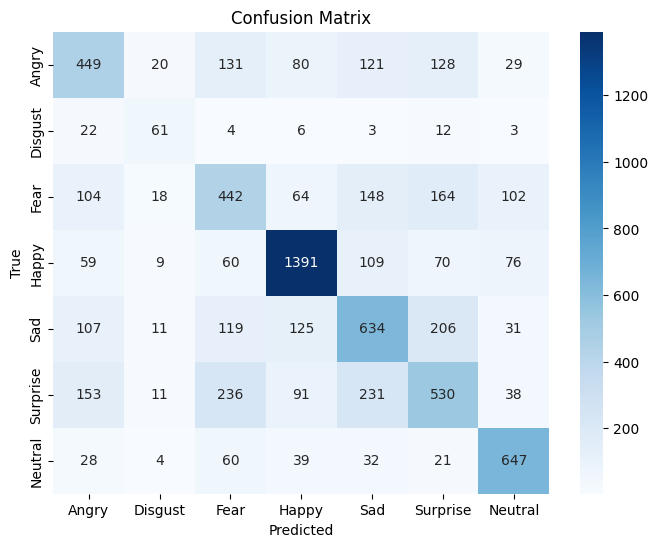

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

class_names = ['Angry','Disgust','Fear','Happy','Sad','Surprise','Neutral']

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


Upload an image


Saving download (13).jfif to download (13).jfif


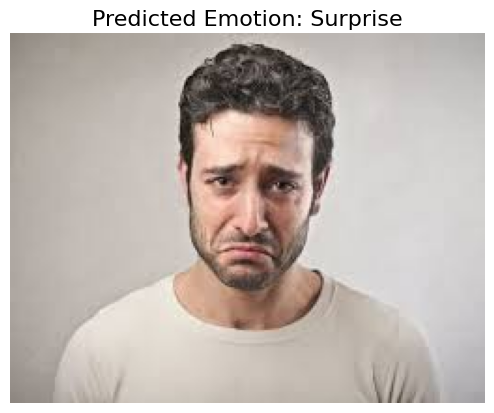


Upload an image


Saving download (12).jfif to download (12).jfif


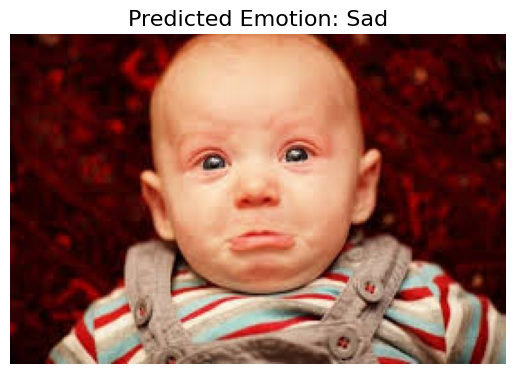


Upload an image


Saving download (14).jfif to download (14).jfif


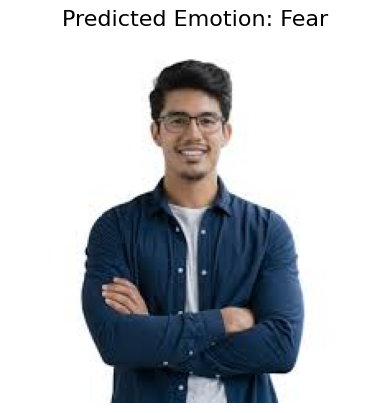


Upload an image



Upload an image


KeyboardInterrupt: 

In [24]:
from google.colab import files
from PIL import Image
import torchvision.transforms as transforms
import torch
import matplotlib.pyplot as plt

classes = ['Angry','Disgust','Fear','Happy','Sad','Surprise','Neutral']

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

model.eval()

while True:
    print("\nUpload an image")

    uploaded = files.upload()

    for filename in uploaded.keys():

        image = Image.open(filename)

        img = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(img)
            _, predicted = torch.max(outputs, 1)

        emotion = classes[predicted.item()]

        plt.imshow(image)
        plt.axis("off")
        plt.title(f"Predicted Emotion: {emotion}", fontsize=16)
        plt.show()


Upload an image to analyze emotion:


Saving download (13).jfif to download (13).jfif


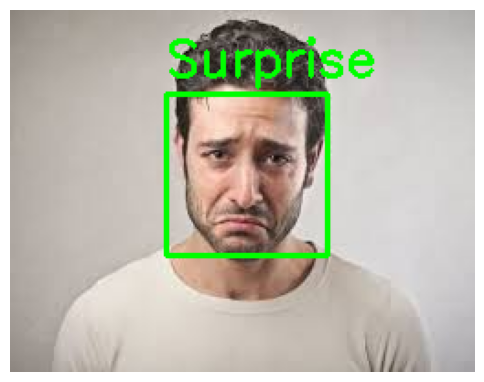


Upload an image to analyze emotion:


Saving download (12).jfif to download (12).jfif


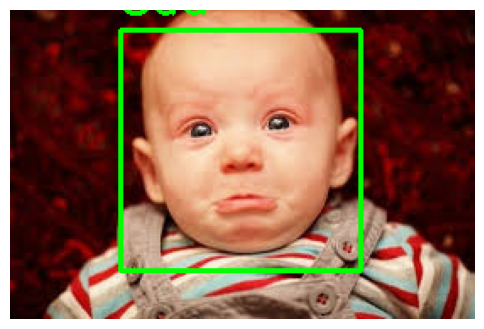


Upload an image to analyze emotion:


Saving download (14).jfif to download (14).jfif


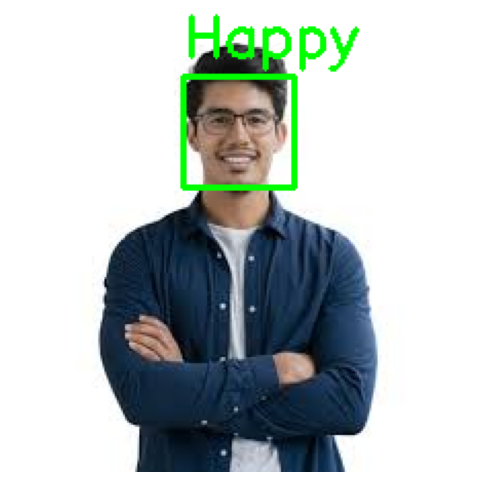


Upload an image to analyze emotion:


KeyboardInterrupt: 

In [19]:
from google.colab import files
from PIL import Image
import cv2
import numpy as np
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

classes = ['Angry','Disgust','Fear','Happy','Sad','Surprise','Neutral']

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

# model in eval mode
model.eval()

# discover face
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

while True:
    print("\nUpload an image to analyze emotion:")
    uploaded = files.upload()

    for filename in uploaded.keys():
        # read image
        image = cv2.imread(filename)
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # discover faces
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

        if len(faces) == 0:
            print("⚠️ No face detected. Try another image.")
            continue

        for (x, y, w, h) in faces:
            face_img = image[y:y+h, x:x+w]
            face_pil = Image.fromarray(cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB))

            img = transform(face_pil).unsqueeze(0).to(device)

            # emotion prediction
            with torch.no_grad():
                outputs = model(img)
                _, predicted = torch.max(outputs, 1)
                emotion = classes[predicted.item()]

            cv2.rectangle(image, (x, y), (x+w, y+h), (0,255,0), 2)
            cv2.putText(image, emotion, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,255,0), 2)

        # display images using matplotlib
        plt.figure(figsize=(6,6))
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()